In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

ml_df = pd.read_csv("Dataset/ML_Train_Level_Data.csv")

ml_df.head()

,Train_No,Journey_Duration_Minutes,Total_Distance,Number_of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,9120.0,2694,14
4,401,2190.0,1618,12


In [2]:
train_idx, test_idx = train_test_split(
    ml_df.index,
    test_size=0.2,
    random_state=42
)

y_train = ml_df.loc[train_idx, "Journey_Duration_Minutes"]
y_test = ml_df.loc[test_idx, "Journey_Duration_Minutes"]

In [3]:
X1_train = ml_df.loc[train_idx, ["Total_Distance"]]
X1_test = ml_df.loc[test_idx, ["Total_Distance"]]

model_1 = LinearRegression()

model_1.fit(X1_train, y_train)

pred_1 = model_1.predict(X1_test)

In [4]:
mae_1 = mean_absolute_error(y_test, pred_1)
rmse_1 = mean_squared_error(y_test, pred_1) ** 0.5

print("Model 1 MAE:", mae_1)
print("Model 1 RMSE:", rmse_1)

Model 1 MAE: 67.50745912668631
Model 1 RMSE: 167.4777430508488


In [5]:
X2_train = ml_df.loc[
    train_idx,
    ["Total_Distance", "Number_of_Stops"]
]

X2_test = ml_df.loc[
    test_idx,
    ["Total_Distance", "Number_of_Stops"]
]

model_2 = LinearRegression()

model_2.fit(X2_train, y_train)

pred_2 = model_2.predict(X2_test)

In [6]:
mae_2 = mean_absolute_error(y_test, pred_2)
rmse_2 = mean_squared_error(y_test, pred_2) ** 0.5

print("Model 2 MAE:", mae_2)
print("Model 2 RMSE:", rmse_2)

Model 2 MAE: 58.726464871794605
Model 2 RMSE: 157.58413024905389


In [7]:
comparison = pd.DataFrame({
    "Model": [
        "Distance Only",
        "Distance + Stops"
    ],
    "MAE": [mae_1, mae_2],
    "RMSE": [rmse_1, rmse_2]
})

comparison

,Model,MAE,RMSE
0,Distance Only,67.507459,167.477743
1,Distance + Stops,58.726465,157.584130


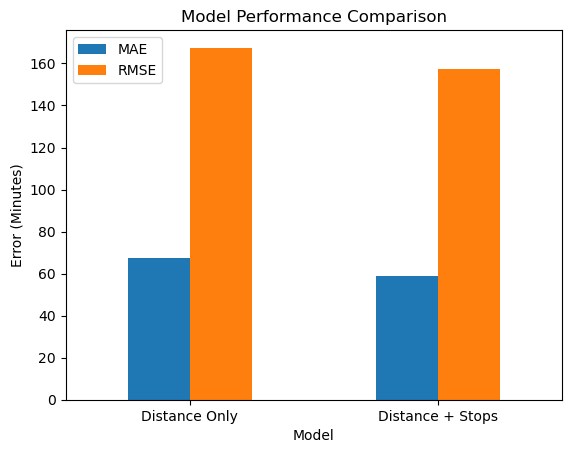

In [8]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar"
)

plt.ylabel("Error (Minutes)")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.show()

Final Model Selection

The Distance + Stops Linear Regression model achieved lower MAE and RMSE compared with the Distance Only model. Therefore, the Distance + Stops model was selected as the final model for train journey duration prediction.